In [44]:
import sys
from pathlib import Path

# Add project root to path
sys.path.append(str(Path("..").resolve()))
from constants import PROCESSED_DATA_FOLDER, ASSETS_FOLDER

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from helpers import ModelData

In [45]:
model_data = ModelData.from_pickle(PROCESSED_DATA_FOLDER / "processed_data_42.pkl")
model_data

ModelData(n_total=921, n_train=500, n_obs=64887)

In [46]:
from constants import DATA_FOLDER

# Dataframes
reviews = pd.read_csv(DATA_FOLDER / "reviews.csv")
business_covariates: pd.DataFrame = (
    model_data.business_covariates
)  # type as dataframe to remove warnings

In [47]:
reviews.head(2)

,review_id,business_id,user_id,date,stars,text,funny,cool,useful,Year,first_year,.groups,n_reviews,AggRat,language,tempcontiguity,sentimenttext,wordCount
0,EQF-SyHb_Yg0HC9E9BppOg,--g-a85VwrdZJNf0R95GcQ,SvsoiaCf0WG7UIDJOxJ7Yg,2013-11-14,5,super fresh food..great prices. ala carte and ...,0,1,3,2013,2013,drop,24,5.0,en,0,0.461132,10
1,qfvzHEL0gGxRdTo7NB2fnw,--g-a85VwrdZJNf0R95GcQ,D0YggUjK98hwIpiqXA9y_g,2013-11-18,5,I was in the Kabab House for the first time on...,0,1,3,2013,2013,drop,24,5.0,en,0,0.287281,44


In [48]:
# add closed column
business_covariates["Closed"] = 1 - business_covariates["is_open"]

business_covariates.head(2)

,business_id,name,neighborhood,address,city,state,postal_code,latitude,longitude,stars,...,category,FT,Price.Level,Restaurant.Size,Number.of.Seats,ZRI,Distance.To.City.Centre,Age,logAge,Closed
0,QkG3KUXwqZBW18A9k1xqCA,"""Red Lobster""",NaN,"""2810 North 75th Ave""",Phoenix,AZ,85035.0,33.478735,-112.221379,2.5,...,American,False,2.0,700.0,350.0,1248.0,14035.314000,2057,7.629004,0
1,FKNvQvsknpNSG26hVtzJ0w,"""Einstein Bros Bagels""",NaN,"""21001 N Tatum Blvd, Ste 80-1650""",Phoenix,AZ,85050.0,33.679394,-111.975243,2.5,...,Salad,False,1.0,250.0,100.0,1638.0,26979.001882,2782,7.930925,0


In [49]:
business_covariates_renamed = business_covariates.rename(
    columns={"stars": "overall_stars"}
)
df_joined = reviews.merge(business_covariates_renamed, on="business_id", how="left")
df_joined["date"] = pd.to_datetime(df_joined["date"])  # convert date to datetime
df_joined.columns

Index(['review_id', 'business_id', 'user_id', 'date', 'stars', 'text', 'funny',
       'cool', 'useful', 'Year', 'first_year', '.groups', 'n_reviews',
       'AggRat', 'language', 'tempcontiguity', 'sentimenttext', 'wordCount',
       'name', 'neighborhood', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'overall_stars', 'review_count', 'is_open',
       'categories', 'Checkin', 'chain', 'density', 'TRAIN', 'category', 'FT',
       'Price.Level', 'Restaurant.Size', 'Number.of.Seats', 'ZRI',
       'Distance.To.City.Centre', 'Age', 'logAge', 'Closed'],
      dtype='object')

## Summary Statistics


In [50]:
########### Summary Statistics (All data) ###################

import pandas as pd

from helpers import build_summary_df

# Calculate time differences between ratings
temp_diff = np.diff(model_data.days)
temp_diff = temp_diff[temp_diff >= 0]  # delete negative values

# helper function to build df with variables as rows and metrics (mean, std) as columns
summary_df = build_summary_df(
    ratings=model_data.ratings,
    temp_diff=temp_diff,
    sentiment=model_data.sentiment,
    time=model_data.time,
    business_covariates=business_covariates,
)

In [51]:
########### Summary Statistics by Business Status (Open vs Closed) ###################

# seperate the data for open and closed businesses to compare metrics for overall, open and closed businesses

open_mask = business_covariates["is_open"] == 1
closed_mask = business_covariates["is_open"] == 0

# calculate days between ratings for each group
temp_diff_open = []
temp_diff_closed = []
start_idx = 0

for i, t in enumerate(model_data.time):
    if t > 1:  # only if business has multiple reviews
        business_days = model_data.days[start_idx : start_idx + t]
        diffs = np.diff(
            business_days
        )  # calculate days between reviews for each business

        if open_mask.iloc[i]:  # business is open
            temp_diff_open.extend(diffs)
        else:  # business is closed
            temp_diff_closed.extend(diffs)

    start_idx += t

temp_diff_open = np.array(temp_diff_open)
temp_diff_open = temp_diff_open[temp_diff_open >= 0]  # Remove negative values

temp_diff_closed = np.array(temp_diff_closed)
temp_diff_closed = temp_diff_closed[temp_diff_closed >= 0]  # Remove negative values

# create business-to-review mapping
review_business_idx = []
for i, t in enumerate(model_data.time):
    review_business_idx.extend([i] * t)
review_business_idx = np.array(review_business_idx)

# get indices of open/closed businesses
open_business_indices = np.where(open_mask)[0]
closed_business_indices = np.where(closed_mask)[0]

# create masks for reviews
open_reviews_mask = np.isin(review_business_idx, open_business_indices)
closed_reviews_mask = np.isin(review_business_idx, closed_business_indices)

# filter review-level data
ratings_open = np.array(model_data.ratings)[open_reviews_mask]
ratings_closed = np.array(model_data.ratings)[closed_reviews_mask]
sentiment_open = np.array(model_data.sentiment)[open_reviews_mask]
sentiment_closed = np.array(model_data.sentiment)[closed_reviews_mask]

# filter business-level data
business_covariates_open = business_covariates[open_mask]
business_covariates_closed = business_covariates[closed_mask]
time_open = np.array(model_data.time)[open_mask]
time_closed = np.array(model_data.time)[closed_mask]
closed_open = np.array(model_data.closed)[open_mask]
closed_closed = np.array(model_data.closed)[closed_mask]

print(f"Open businesses: {len(business_covariates_open)}")
print(f"Closed businesses: {len(business_covariates_closed)}")
print(f"Open reviews: {len(ratings_open)}")
print(f"Closed reviews: {len(ratings_closed)}")

Open businesses: 696
Closed businesses: 225
Open reviews: 50472
Closed reviews: 14415


In [52]:
summary_open_df = build_summary_df(
    ratings=ratings_open,
    temp_diff=temp_diff_open,
    sentiment=sentiment_open,
    time=time_open,
    business_covariates=business_covariates_open,
)

In [53]:
summary_closed_df = build_summary_df(
    ratings=ratings_closed,
    temp_diff=temp_diff_closed,
    sentiment=sentiment_closed,
    time=time_closed,
    business_covariates=business_covariates_closed,
)

In [54]:
print(60 * "=")
print("SUMMARY STATISTICS:")
print(60 * "=")

print("For all businesses:")
display(summary_df)


print("For businesses that are still open:")
display(summary_open_df)

print("For businesses that closed:")
display(summary_closed_df)

SUMMARY STATISTICS:
For all businesses:


,Variable,Mean,SD
0,Rating,3.70,1.46
1,Days Between Ratings,19.39,43.81
2,Sentiment,0.08,0.37
3,Density,12.71,14.81
4,Age (in months),48.10,29.48
5,Check-in rate,5.60,6.66
6,Chain status,0.29,0.45
7,Rent level (Zillow Rent Index),1492.52,179.94
8,Restaurant Size (in m^2),228.81,259.85
9,Number of Seats,98.10,103.88


For businesses that are still open:


,Variable,Mean,SD
0,Rating,3.71,1.48
1,Days Between Ratings,20.37,45.72
2,Sentiment,0.08,0.37
3,Density,12.08,13.72
4,Age (in months),52.02,30.66
5,Check-in rate,5.50,6.99
6,Chain status,0.36,0.48
7,Rent level (Zillow Rent Index),1482.54,184.17
8,Restaurant Size (in m^2),231.32,273.76
9,Number of Seats,98.74,105.49


For businesses that closed:


,Variable,Mean,SD
0,Rating,3.69,1.40
1,Days Between Ratings,15.98,36.13
2,Sentiment,0.08,0.35
3,Density,14.67,17.66
4,Age (in months),35.98,21.38
5,Check-in rate,5.93,5.53
6,Chain status,0.05,0.22
7,Rent level (Zillow Rent Index),1524.22,162.15
8,Restaurant Size (in m^2),216.18,173.72
9,Number of Seats,94.72,95.23


In [55]:
######## Price Levels ###########
price_levels = {"Price Level": [], "Mean": [], "SD": []}

level_to_label = {1: "<10$", 2: "11-30$", 3: "31-60$", 4: ">60$"}

for lvl in range(1, 4 + 1):
    price_levels["Price Level"].append(f"{lvl} ({level_to_label[lvl]})")
    price_levels["Mean"].append(np.mean(business_covariates["Price.Level"] == lvl))
    price_levels["SD"].append(np.std(business_covariates["Price.Level"] == lvl, ddof=1))

price_df = pd.DataFrame(price_levels)
price_df

,Price Level,Mean,SD
0,1 (<10$),0.527687,0.499504
1,2 (11-30$),0.435396,0.496078
2,3 (31-60$),0.008686,0.092845
3,4 (>60$),0.000000,0.000000


In [56]:
############ Restaurant Categories ################

# get all category columns
category_unique = business_covariates["category"].unique()

# calculate metrics for each category column
category_stats = {"Category": [], "Mean": [], "SD": []}

for cat in category_unique:
    indicator = (business_covariates["category"] == cat).astype(float)
    category_stats["Category"].append(cat)
    category_stats["Mean"].append(np.mean(indicator))
    category_stats["SD"].append(np.std(indicator, ddof=1))

category_df = pd.DataFrame(category_stats)
category_df

,Category,Mean,SD
0,American,0.257329,0.437400
1,Salad,0.035831,0.185969
2,Asian,0.124864,0.330745
3,Pizza,0.092291,0.289594
4,Fast Food,0.108578,0.311278
5,Mexican,0.174810,0.380011
6,Cafes,0.087948,0.283373
7,Other,0.064061,0.244994
8,Speciality Food,0.054289,0.226710


## Rating Statistics by Failure Status

Comparison of average valence, variance, and entropy between open and closed restaurants


In [57]:
from helpers import comp_entropy

# Compute rating mean, variance and entropy for each restaurant
review_stats_per_business = (
    reviews.groupby("business_id")["stars"]
    .agg(
        [("VAR", lambda x: np.var(x, ddof=1)), ("MEAN", "mean"), ("ENTR", comp_entropy)]
    )
    .reset_index()
)

# Join with business covariates and get relevant columns
business_rating_stats = business_covariates.merge(
    review_stats_per_business, on="business_id", how="left"
)
business_rating_stats = business_rating_stats[["is_open", "VAR", "MEAN", "ENTR"]].copy()
business_rating_stats["Status"] = business_rating_stats["is_open"].map(
    {0: "Closed", 1: "Open"}
)

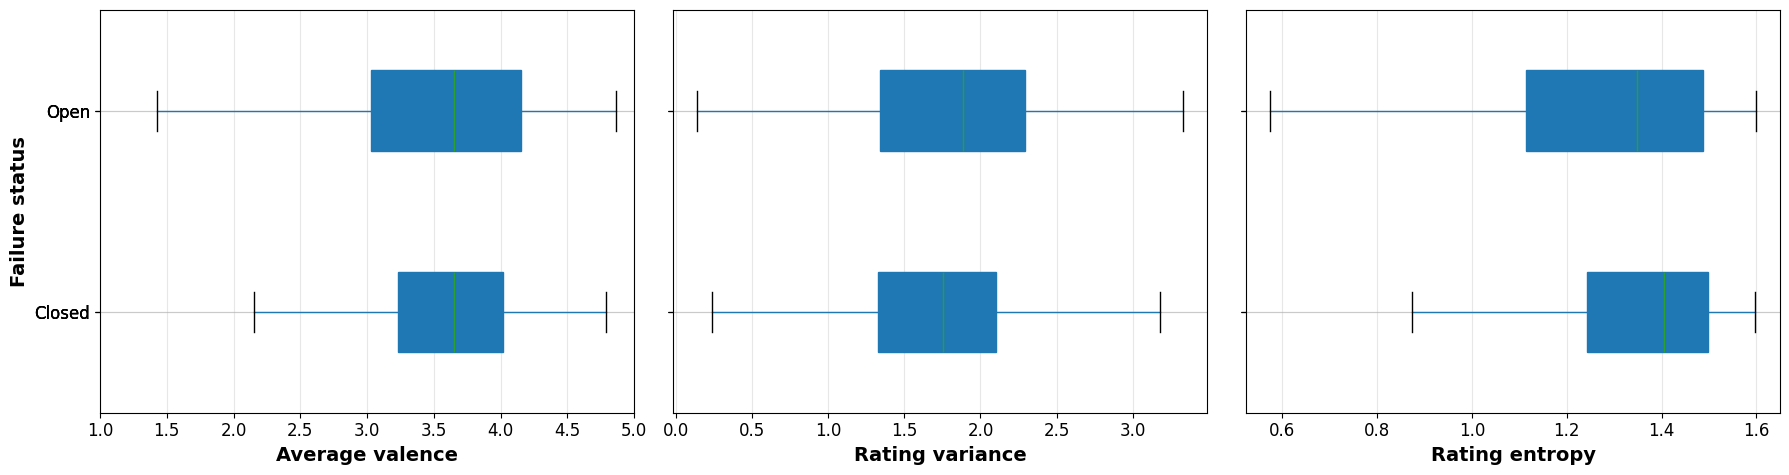


Figure 2 saved to: /Users/omidsedighi-mornani/Desktop/STUDIUM WIRTSCHAFTSINFORMATIK/Semester 5/Seminar Gust/SourceCode/assets/rating_statistics_all.png


In [58]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Define colors for each status
colors = {"Closed": "#d62728", "Open": "#2ca02c"}

# Plot 1: Average Valence (MEAN)
bp1 = business_rating_stats.boxplot(
    column="MEAN",
    by="Status",
    ax=axes[0],
    patch_artist=True,
    showfliers=False,
    vert=False,
    widths=0.4,
    return_type="dict",
)

axes[0].set_xlabel("Average valence", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Failure status", fontsize=14, fontweight="bold")
axes[0].set_title("")
axes[0].set_xlim(1, 5)
axes[0].tick_params(labelsize=12)
axes[0].grid(alpha=0.3)

# Color boxes
for patch, status in zip(axes[0].artists, ["Closed", "Open"]):
    patch.set_facecolor(colors[status])
    patch.set_alpha(0.7)

# Plot 2: Rating Variance (VAR)
bp2 = business_rating_stats.boxplot(
    column="VAR",
    by="Status",
    ax=axes[1],
    patch_artist=True,
    showfliers=False,
    vert=False,
    widths=0.4,
    return_type="dict",
)

axes[1].set_xlabel("Rating variance", fontsize=14, fontweight="bold")
axes[1].set_ylabel("")
axes[1].set_title("")
axes[1].tick_params(axis="y", labelleft=False)
axes[1].tick_params(labelsize=12)
axes[1].grid(alpha=0.3)

# Color boxes
for patch, status in zip(axes[1].artists, ["Closed", "Open"]):
    patch.set_facecolor(colors[status])
    patch.set_alpha(0.7)

# Plot 3: Rating Entropy (ENTR)
bp3 = business_rating_stats.boxplot(
    column="ENTR",
    by="Status",
    ax=axes[2],
    patch_artist=True,
    showfliers=False,
    vert=False,
    widths=0.4,
    return_type="dict",
)

axes[2].set_xlabel("Rating entropy", fontsize=14, fontweight="bold")
axes[2].set_ylabel("")
axes[2].set_title("")
axes[2].tick_params(axis="y", labelleft=False)
axes[2].tick_params(labelsize=12)
axes[2].grid(alpha=0.3)

# Color boxes
for patch, status in zip(axes[2].artists, ["Closed", "Open"]):
    patch.set_facecolor(colors[status])
    patch.set_alpha(0.7)

# Remove automatic title from pandas boxplot
fig.suptitle("")

plt.tight_layout()
plt.savefig(
    ASSETS_FOLDER / "rating_statistics_all.png",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
)
plt.show()

print("\nFigure 2 saved to:", ASSETS_FOLDER / "rating_statistics_all.png")

### Statistical Tests: Mann-Whitney U Test

Testing for significant differences between open and closed restaurants


In [59]:
from scipy.stats import mannwhitneyu


def mannwhitneyu_test(df):
    # Prepare data for Mann-Whitney U test
    df_clean = df.dropna(subset=["MEAN", "VAR", "ENTR"])
    failure = df_clean[df_clean["Status"] == "Closed"]
    in_business = df_clean[df_clean["Status"] == "Open"]

    print("=" * 80)
    print("MANN-WHITNEY U TEST RESULTS")
    print("=" * 80)

    # Test 1: Average Valence (MEAN)
    stat_mean, p_mean = mannwhitneyu(
        failure["MEAN"], in_business["MEAN"], alternative="two-sided"
    )
    print(f"\n1. Average Valence (MEAN):")
    print(f"   U-statistic: {stat_mean:.2f}")
    print(f"   p-value: {p_mean:.4f}")
    print(f"   Significant: {'Yes' if p_mean < 0.05 else 'No'} (α = 0.05)")

    # Test 2: Rating Variance (VAR)
    stat_var, p_var = mannwhitneyu(
        failure["VAR"], in_business["VAR"], alternative="two-sided"
    )
    print(f"\n2. Rating Variance (VAR):")
    print(f"   U-statistic: {stat_var:.2f}")
    print(f"   p-value: {p_var:.4f}")
    print(f"   Significant: {'Yes' if p_var < 0.05 else 'No'} (α = 0.05)")

    # Test 3: Rating Entropy (ENTR)
    stat_entr, p_entr = mannwhitneyu(
        failure["ENTR"], in_business["ENTR"], alternative="two-sided"
    )
    print(f"\n3. Rating Entropy (ENTR):")
    print(f"   U-statistic: {stat_entr:.2f}")
    print(f"   p-value: {p_entr:.4f}")
    print(f"   Significant: {'Yes' if p_entr < 0.05 else 'No'} (α = 0.05)")

In [60]:
mannwhitneyu_test(business_rating_stats)

MANN-WHITNEY U TEST RESULTS

1. Average Valence (MEAN):
   U-statistic: 78692.50
   p-value: 0.9100
   Significant: No (α = 0.05)

2. Rating Variance (VAR):
   U-statistic: 71421.00
   p-value: 0.0474
   Significant: Yes (α = 0.05)

3. Rating Entropy (ENTR):
   U-statistic: 88235.50
   p-value: 0.0042
   Significant: Yes (α = 0.05)


**Interpretation:**

- **Average Valence (Mean)**: No significant difference in average ratings between open and closed restaurants (p > 0.05)
- **Rating Variance**: Significant difference detected (p < 0.05) - closed restaurants show higher variance in ratings
- **Rating Entropy**: Highly significant difference (p < 0.01) - closed restaurants show higher entropy, indicating more dispersed rating distributions


## Rating Trajectories Over Review Sequence

This analysis examines how **average ratings** evolve over the review sequence to identify patterns that may signal business decline.

**What does this analysis show?**

- **X-axis**: Review sequence number (1st, 2nd, 3rd, ... review per restaurant)
- **Y-axis**: Average rating (stars)
- **Two trajectories**: Red for closed restaurants, Blue for open restaurants

**Key Insights:**

- **Declining ratings** → Deteriorating service/product quality → Potential indicator of business problems
- **Steeper decline for closed restaurants** → Suggests worsening performance before closure
- Rating trends can serve as direct quality indicators and early warning signals

**Expected Pattern:**
If closed restaurants show a downward rating trend compared to open restaurants, this suggests declining quality or customer satisfaction preceded business failure.

**Actual:**
No clear upwards or downwards trend seen (high variance at the end).


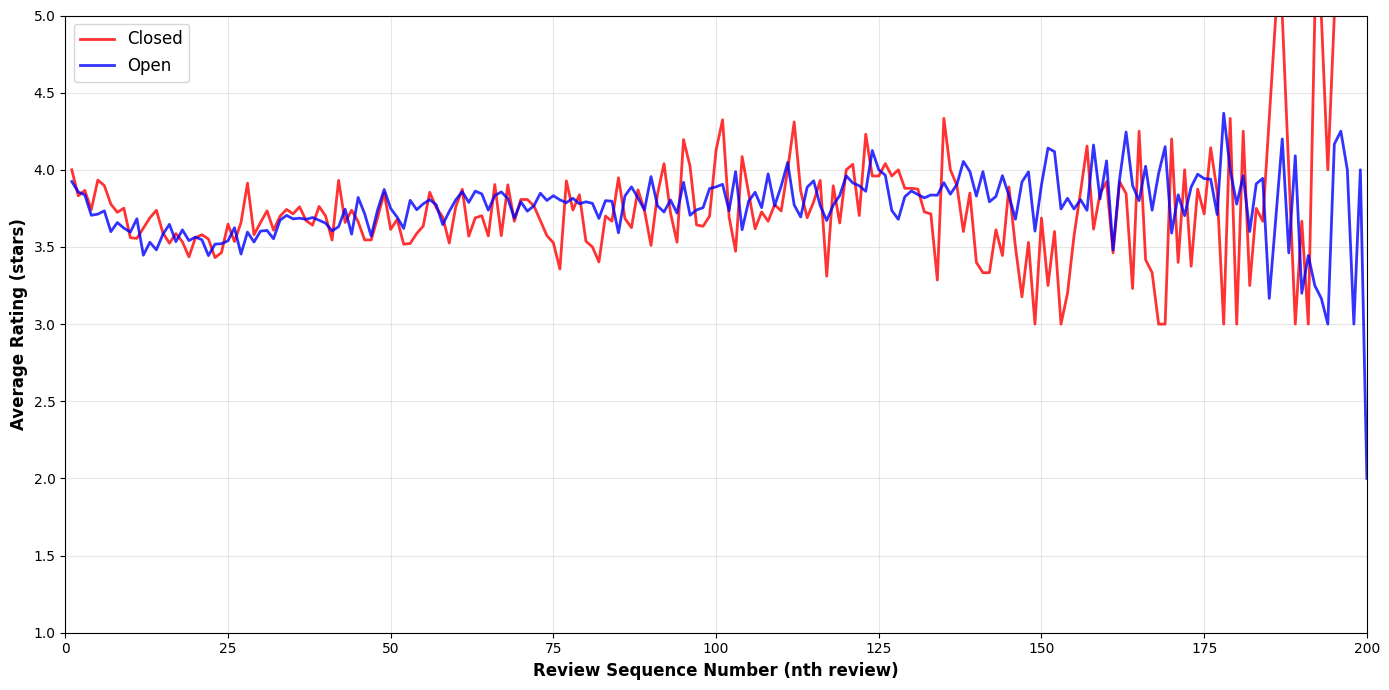


RATING TRAJECTORY STATISTICS

Overall Average Rating:
  Closed restaurants: 3.7394
  Open restaurants: 3.7628
  Difference: -0.0234

Average Rating (First 50 Reviews):
  Closed restaurants: 3.6751
  Open restaurants: 3.6376

Average Rating (After 150 Reviews):
  Closed restaurants: 3.8107
  Open restaurants: 3.7723


In [61]:
# Sort by business and date
ratings_with_status_sorted = df_joined.sort_values(
    ["business_id", "date"], ascending=[True, True]
).copy()

# Add review sequence number (1st, 2nd, 3rd, ... review per restaurant)
ratings_with_status_sorted["review_number"] = (
    ratings_with_status_sorted.groupby("business_id").cumcount() + 1
)

# Calculate average rating per review sequence number for each group
avg_rating_closed = (
    ratings_with_status_sorted[ratings_with_status_sorted["is_open"] == 0]
    .groupby("review_number")["stars"]
    .mean()
    .reset_index()
)
avg_rating_closed["status"] = "Closed"

avg_rating_open = (
    ratings_with_status_sorted[ratings_with_status_sorted["is_open"] == 1]
    .groupby("review_number")["stars"]
    .mean()
    .reset_index()
)
avg_rating_open["status"] = "Open"

# Combine
rating_trajectory = pd.concat([avg_rating_closed, avg_rating_open], ignore_index=True)

# Plot
plt.figure(figsize=(14, 7))

for status, color in zip(["Closed", "Open"], ["red", "blue"]):
    data = rating_trajectory[rating_trajectory["status"] == status]
    plt.plot(
        data["review_number"],
        data["stars"],
        label=status,
        color=color,
        alpha=0.8,
        linewidth=2,
    )

plt.xlabel("Review Sequence Number (nth review)", fontsize=12, fontweight="bold")
plt.ylabel("Average Rating (stars)", fontsize=12, fontweight="bold")

plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.xlim(0, len(data))
plt.ylim(1, 5)
plt.tight_layout()

plt.savefig(
    ASSETS_FOLDER / "rating_trajectories.png",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
)
plt.show()

# Print summary statistics
print("\n" + "=" * 80)
print("RATING TRAJECTORY STATISTICS")
print("=" * 80)

# Overall averages
overall_closed = avg_rating_closed["stars"].mean()
overall_open = avg_rating_open["stars"].mean()

print(f"\nOverall Average Rating:")
print(f"  Closed restaurants: {overall_closed:.4f}")
print(f"  Open restaurants: {overall_open:.4f}")
print(f"  Difference: {overall_closed - overall_open:.4f}")

# Early vs Late comparison
early_closed = avg_rating_closed[avg_rating_closed["review_number"] <= 50][
    "stars"
].mean()
early_open = avg_rating_open[avg_rating_open["review_number"] <= 50]["stars"].mean()

late_closed = avg_rating_closed[avg_rating_closed["review_number"] > 150][
    "stars"
].mean()
late_open = avg_rating_open[avg_rating_open["review_number"] > 150]["stars"].mean()

print(f"\nAverage Rating (First 50 Reviews):")
print(f"  Closed restaurants: {early_closed:.4f}")
print(f"  Open restaurants: {early_open:.4f}")

print(f"\nAverage Rating (After 150 Reviews):")
print(f"  Closed restaurants: {late_closed:.4f}")
print(f"  Open restaurants: {late_open:.4f}")

## Temporal Gaps Between Ratings


### Interarrival Times Analysis

This analysis examines the **temporal patterns** of review arrivals to identify potential warning signals of business failure.

**What are Interarrival Times?**

- The number of days between consecutive reviews for each restaurant
- A measure of customer engagement and business activity

**What does this plot show?**

- **X-axis**: Review sequence number (1st, 2nd, 3rd, ... review per restaurant)
- **Y-axis**: Average days since the last rating
- **Two trajectories**: Red for closed restaurants, Blue for open restaurants

**Key Insights:**

- **Increasing interarrival times** → Longer gaps between reviews → Declining customer frequency
- **Steeper slope for closed restaurants** → Indicates accelerating decline in customer traffic before closure
- This pattern can serve as an **early warning signal** for business failure

**Expected Pattern:**
If closed restaurants show a steeper upward trend than open restaurants, this suggests that declining customer frequency (measured by increasing time gaps between reviews) preceded business closure.

**Actual Pattern:**
Large jumps in time differences can be observed at the end of the review sequence. This is likely due to high variance, as only a few businesses have such a large number of reviews.
Otherwise, the time gap for closed as well as open businesses remain stable.


<>:94: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
<>:94: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
/var/folders/hc/g9ymkbv17hbdwc11nytysx7m0000gn/T/ipykernel_42846/2877120078.py:94: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
  print(f"\Highest Interarrival Time (After 150 Reviews):")


Total interarrival intervals: 58718


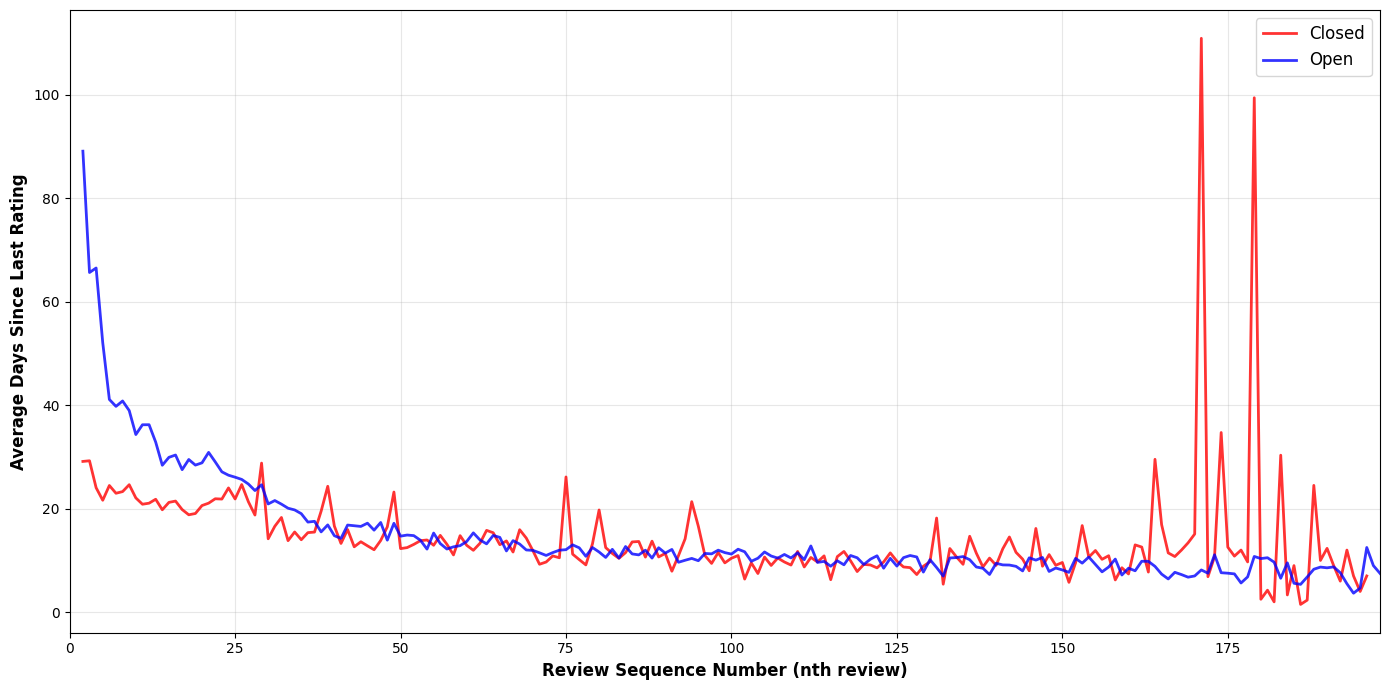


INTERARRIVAL TIME TRAJECTORY STATISTICS

Average Interarrival Time (After 150 Reviews):
  Closed restaurants: 15.11 days
  Open restaurants: 8.00 days
\Highest Interarrival Time (After 150 Reviews):
  Closed restaurants: 110.89 days
  Open restaurants: 12.50 days


In [66]:
# Sort by business and date
reviews_with_status_sorted = df_joined.sort_values(
    ["business_id", "date"], ascending=[True, True]
).copy()

# Calculate days since last review within each business
reviews_with_status_sorted["days_since_last"] = (
    reviews_with_status_sorted.groupby("business_id")["date"].diff().dt.days
)

# Add review sequence number (1st, 2nd, 3rd, ... review per restaurant)
reviews_with_status_sorted["review_number"] = (
    reviews_with_status_sorted.groupby("business_id").cumcount() + 1
)

# Remove first review per business (no previous review to compare)
interarrival_data = reviews_with_status_sorted[
    reviews_with_status_sorted["days_since_last"].notna()
].copy()

# Keep only positive values
interarrival_data = interarrival_data[interarrival_data["days_since_last"] > 0]

print(f"Total interarrival intervals: {len(interarrival_data)}")

# Calculate average interarrival time per review sequence number for each group
avg_interarrival_closed = (
    interarrival_data[interarrival_data["is_open"] == 0]
    .groupby("review_number")["days_since_last"]
    .mean()
    .reset_index()
)
avg_interarrival_closed["status"] = "Closed"

avg_interarrival_open = (
    interarrival_data[interarrival_data["is_open"] == 1]
    .groupby("review_number")["days_since_last"]
    .mean()
    .reset_index()
)
avg_interarrival_open["status"] = "Open"

# Combine
trajectory_data = pd.concat(
    [avg_interarrival_closed, avg_interarrival_open], ignore_index=True
)

# Plot
plt.figure(figsize=(14, 7))

for status, color in zip(["Closed", "Open"], ["red", "blue"]):
    data = trajectory_data[trajectory_data["status"] == status]
    plt.plot(
        data["review_number"],
        data["days_since_last"],
        label=status,
        color=color,
        alpha=0.8,
        linewidth=2,
    )

plt.xlabel("Review Sequence Number (nth review)", fontsize=12, fontweight="bold")
plt.ylabel("Average Days Since Last Rating", fontsize=12, fontweight="bold")
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.xlim(0, len(data))  # Limit to maximum review count a restaurant has had
plt.tight_layout()

plt.savefig(
    ASSETS_FOLDER / "time_gaps_trajectoy.png",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
)
plt.show()

# Print summary statistics
print("\n" + "=" * 80)
print("INTERARRIVAL TIME TRAJECTORY STATISTICS")
print("=" * 80)

# Average for late reviews (after 150)
late_closed = avg_interarrival_closed[avg_interarrival_closed["review_number"] > 150][
    "days_since_last"
]
late_open = avg_interarrival_open[avg_interarrival_open["review_number"] > 150][
    "days_since_last"
]

print(f"\nAverage Interarrival Time (After 150 Reviews):")
print(f"  Closed restaurants: {late_closed.mean():.2f} days")
print(f"  Open restaurants: {late_open.mean():.2f} days")

print(f"\Highest Interarrival Time (After 150 Reviews):")
print(f"  Closed restaurants: {late_closed.max():.2f} days")
print(f"  Open restaurants: {late_open.max():.2f} days")

## Average Sentiment

This analysis examines how **review sentiment** evolves over time to identify patterns that may signal business decline.

**What does this analysis show?**

- **X-axis**: Review sequence number (1st, 2nd, 3rd, ... review per restaurant)
- **Y-axis**: Average sentiment score
- **Two trajectories**: Red for closed restaurants, Blue for open restaurants

**Key Insights:**

- **Declining sentiment** → More negative reviews → Potential indicator of declining quality
- **Steeper decline for closed restaurants** → Suggests deteriorating customer satisfaction
- Sentiment trends can complement rating data to provide early warning signals

**Expected Pattern:**
If closed restaurants show a downward sentiment trend compared to open restaurants, this suggests declining customer satisfaction preceded business failure.

**Actual Pattern:**
Although the trend for closed businesses appears to decline towards the end, the variance increases significantly. This is because fewer restaurants have a large number of reviews, leading to greater variability in the averages for higher review counts.


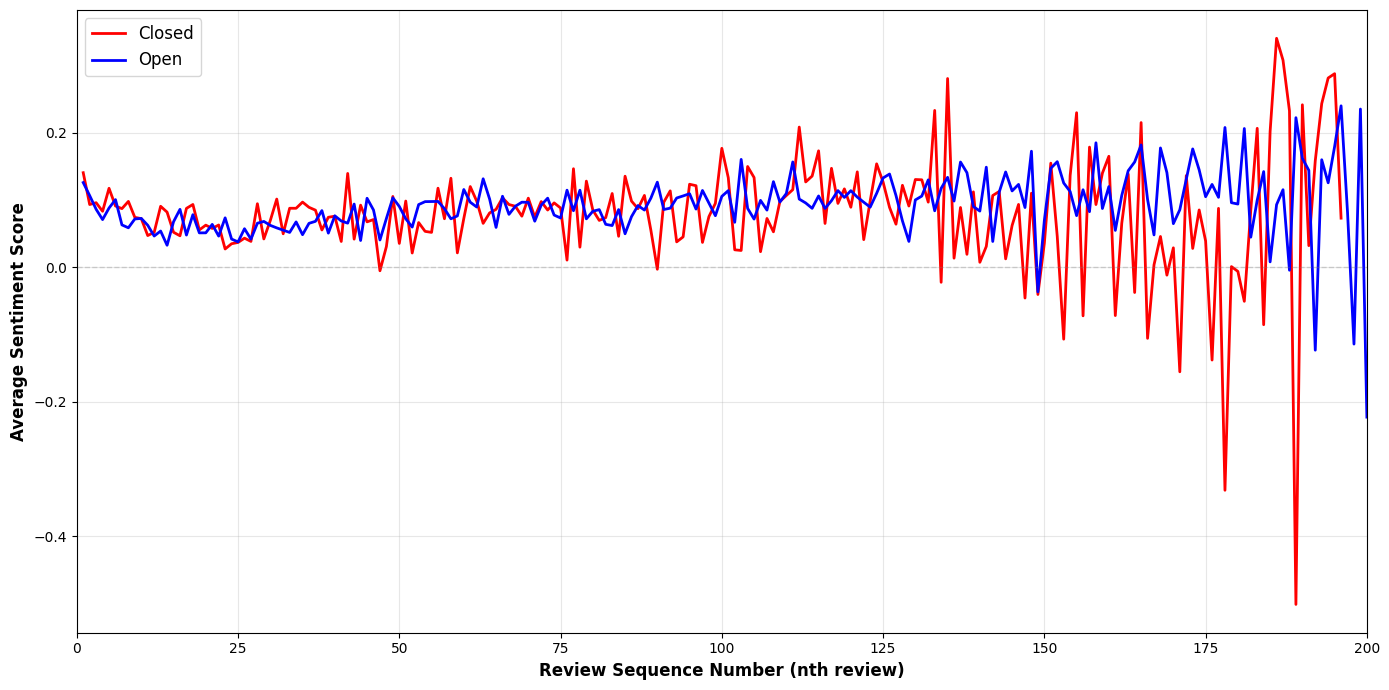


SENTIMENT TRAJECTORY STATISTICS

Overall Average Sentiment:
  Closed restaurants: 0.0779
  Open restaurants: 0.0921
  Difference: -0.0142

Average Sentiment (After 150 Reviews):
  Closed restaurants: 0.0656
  Open restaurants: 0.1086
  Difference: -0.0429


In [65]:
# Sort by business and date
sentiment_reviews_sorted = df_joined.sort_values(
    ["business_id", "date"], ascending=[True, True]
)

# Add review sequence number per restaurant
sentiment_reviews_sorted["review_number"] = (
    sentiment_reviews_sorted.groupby("business_id").cumcount() + 1
)

# Remove rows with missing sentiment
sentiment_reviews_sorted = sentiment_reviews_sorted.dropna(subset=["sentimenttext"])


# Calculate average sentiment per review sequence number for each group
avg_sentiment_closed = (
    sentiment_reviews_sorted[sentiment_reviews_sorted["is_open"] == 0]
    .groupby("review_number")["sentimenttext"]
    .mean()
    .reset_index()
)
avg_sentiment_closed["status"] = "Closed"

avg_sentiment_open = (
    sentiment_reviews_sorted[sentiment_reviews_sorted["is_open"] == 1]
    .groupby("review_number")["sentimenttext"]
    .mean()
    .reset_index()
)
avg_sentiment_open["status"] = "Open"

# Combine
sentiment_trajectory = pd.concat(
    [avg_sentiment_closed, avg_sentiment_open], ignore_index=True
)

# Plot
plt.figure(figsize=(14, 7))

for status, color in zip(["Closed", "Open"], ["red", "blue"]):
    data = sentiment_trajectory[sentiment_trajectory["status"] == status]

    plt.plot(
        data["review_number"],
        data["sentimenttext"],
        label=status,
        color=color,
        linewidth=2,
    )


plt.xlabel("Review Sequence Number (nth review)", fontsize=12, fontweight="bold")
plt.ylabel("Average Sentiment Score", fontsize=12, fontweight="bold")
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.xlim(0, len(data))
plt.axhline(y=0, color="gray", linestyle="--", linewidth=1, alpha=0.3)  # Zero line
plt.tight_layout()

plt.savefig(
    ASSETS_FOLDER / "sentiment_trajectory.png",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
)
plt.show()

# Print summary statistics
print("\n" + "=" * 80)
print("SENTIMENT TRAJECTORY STATISTICS")
print("=" * 80)

# Overall averages
overall_closed = avg_sentiment_closed["sentimenttext"].mean()
overall_open = avg_sentiment_open["sentimenttext"].mean()

print(f"\nOverall Average Sentiment:")
print(f"  Closed restaurants: {overall_closed:.4f}")
print(f"  Open restaurants: {overall_open:.4f}")
print(f"  Difference: {overall_closed - overall_open:.4f}")

# Early vs Late comparison
early_closed = avg_sentiment_closed[avg_sentiment_closed["review_number"] <= 50][
    "sentimenttext"
].mean()
early_open = avg_sentiment_open[avg_sentiment_open["review_number"] <= 50][
    "sentimenttext"
].mean()

late_closed = avg_sentiment_closed[avg_sentiment_closed["review_number"] > 150][
    "sentimenttext"
].mean()
late_open = avg_sentiment_open[avg_sentiment_open["review_number"] > 150][
    "sentimenttext"
].mean()


print(f"\nAverage Sentiment (After 150 Reviews):")
print(f"  Closed restaurants: {late_closed:.4f}")
print(f"  Open restaurants: {late_open:.4f}")
print(f"  Difference: {late_closed - late_open:.4f}")

# Calculate sentiment change
change_closed = late_closed - early_closed
change_open = late_open - early_open

## Geographic Distribution of Restaurants

This map shows the **spatial distribution** of restaurants in Phoenix, Arizona, colored by their operational status.

**What does this map show?**

- **Red dots**: Closed restaurants
- **Blue dots**: Open restaurants
- Geographic coordinates show actual restaurant locations

**Key Insights:**

- Identify geographic clusters of closed vs. open restaurants
- Assess whether business failures are concentrated in specific areas
- Understand spatial patterns that may correlate with business success


Open restaurants: 696
Closed restaurants: 225


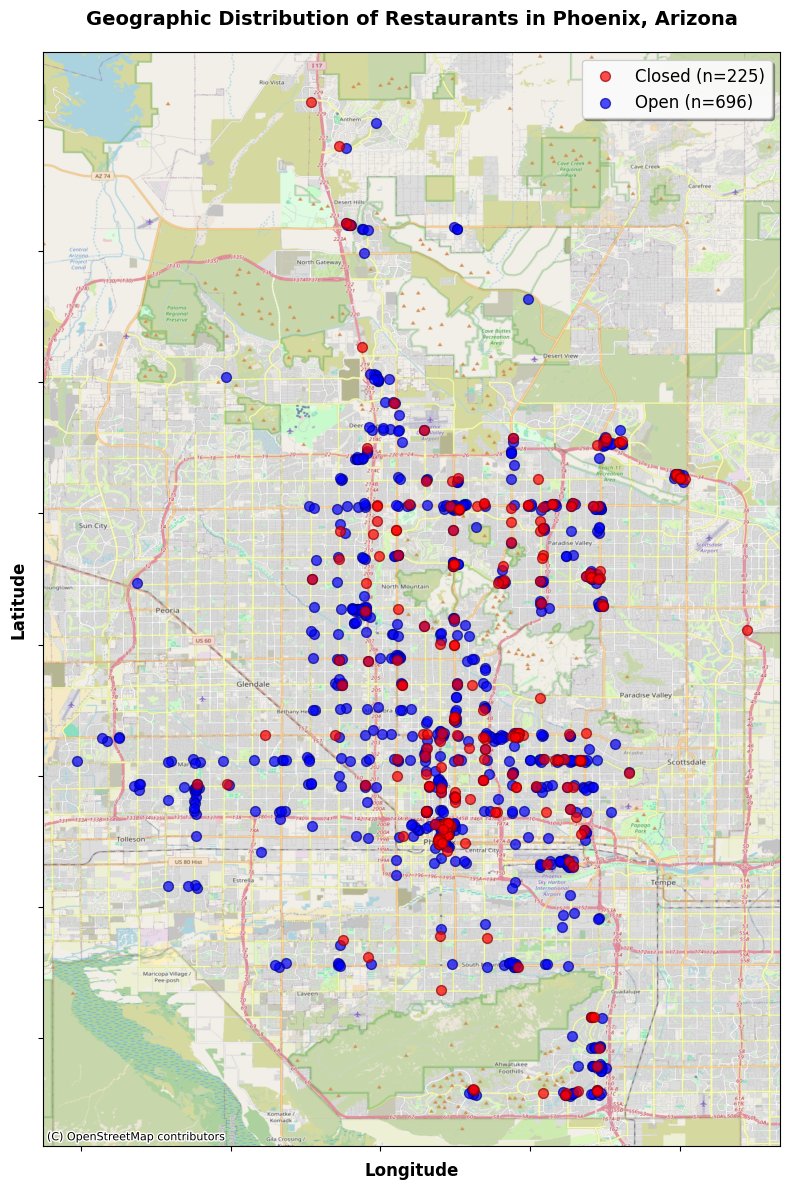

In [64]:
import contextily as ctx
from pyproj import Transformer

# Prepare geographic data
geo_data = business_covariates[
    ["business_id", "latitude", "longitude", "is_open", "name"]
].copy()

print(f"Open restaurants: {len(geo_data[geo_data['is_open'] == 1])}")
print(f"Closed restaurants: {len(geo_data[geo_data['is_open'] == 0])}")

# Convert lat/lon to Web Mercator projection (required for contextily)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
geo_data["x"], geo_data["y"] = transformer.transform(
    geo_data["longitude"].values, geo_data["latitude"].values
)

# Separate open and closed restaurants
open_restaurants = geo_data[geo_data["is_open"] == 1]
closed_restaurants = geo_data[geo_data["is_open"] == 0]

# Create the map
fig, ax = plt.subplots(figsize=(8, 12))

# Plot closed restaurants (red)
ax.scatter(
    closed_restaurants["x"],
    closed_restaurants["y"],
    c="red",
    alpha=0.7,
    s=50,
    label=f"Closed (n={len(closed_restaurants)})",
    edgecolors="darkred",
    linewidth=1,
    zorder=5,  # set z-index higher than open restaurants (blue) to emphasise closed restaurants
)

# Plot open restaurants (blue)
ax.scatter(
    open_restaurants["x"],
    open_restaurants["y"],
    c="blue",
    alpha=0.7,
    s=50,
    label=f"Open (n={len(open_restaurants)})",
    edgecolors="darkblue",
    linewidth=1,
    zorder=4,
)

# Add basemap from OpenStreetMap
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=12,
    attribution_size=8,
)

# Add labels and title
ax.set_xlabel("Longitude", fontsize=12, fontweight="bold")
ax.set_ylabel("Latitude", fontsize=12, fontweight="bold")
ax.set_title(
    "Geographic Distribution of Restaurants in Phoenix, Arizona",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

# Add legend
ax.legend(fontsize=12, loc="upper right", framealpha=0.95, shadow=True)

# Remove tick labels (they're in Web Mercator coordinates, not useful)
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.tight_layout()

# Save the figure
plt.savefig(
    ASSETS_FOLDER / "geographic_distribution.png",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
)
plt.show()

Open and closed businesses are scattered anywhere, which is why it is not possible to build meaningful clusters.

Businesses located closer to the city center and in denser areas have a higher incidence of closure.
This could indicate a relationship, however, this relationship is already accounted for by the 'Density' and 'Distance.To.City.Centre' variables.
